# Results of evaluation: `radiometric`

### These are DRAFT exploratory results

### Legion

Paul Montesano, PhD  
June 2026

In [39]:
library(tidyverse)
library(patchwork)

In [40]:
MAINDIR = '/explore/nobackup/projects/CSDA_eval/results/maxar/legion/radiometric'

band_colors <- c(
  'Coastal'  = '#4f3a89', 'Blue'     = '#1f78b4',
  'Green'    = '#33a02c', 'Yellow'   = '#ffd92f',
  'Red'      = '#e31a1c', 'RedEdge1' = '#b15928',
  'RedEdge2' = '#8b3a00', 'NIR1'     = 'black' #'#525252'
)

sat_colors <- c(
  'LG01' = '#1b9e77', 'LG02' = '#d95f02', 'LG03' = '#7570b3',
  'LG04' = '#e7298a', 'LG05' = '#66a61e', 'LG06' = '#e6ab02',
  'LG07' = '#a6761d', 'LG08' = '#666666', 'LG09' = '#1f78b4'
)

In [41]:
source('../lib/eval_sites_overview.R')

rnaturalearth unavailable, reading continents from local file...

Warning message in st_cast.sf(., "LINESTRING", do_split = TRUE):
“repeating attributes for all sub-geometries for which they may not be constant”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


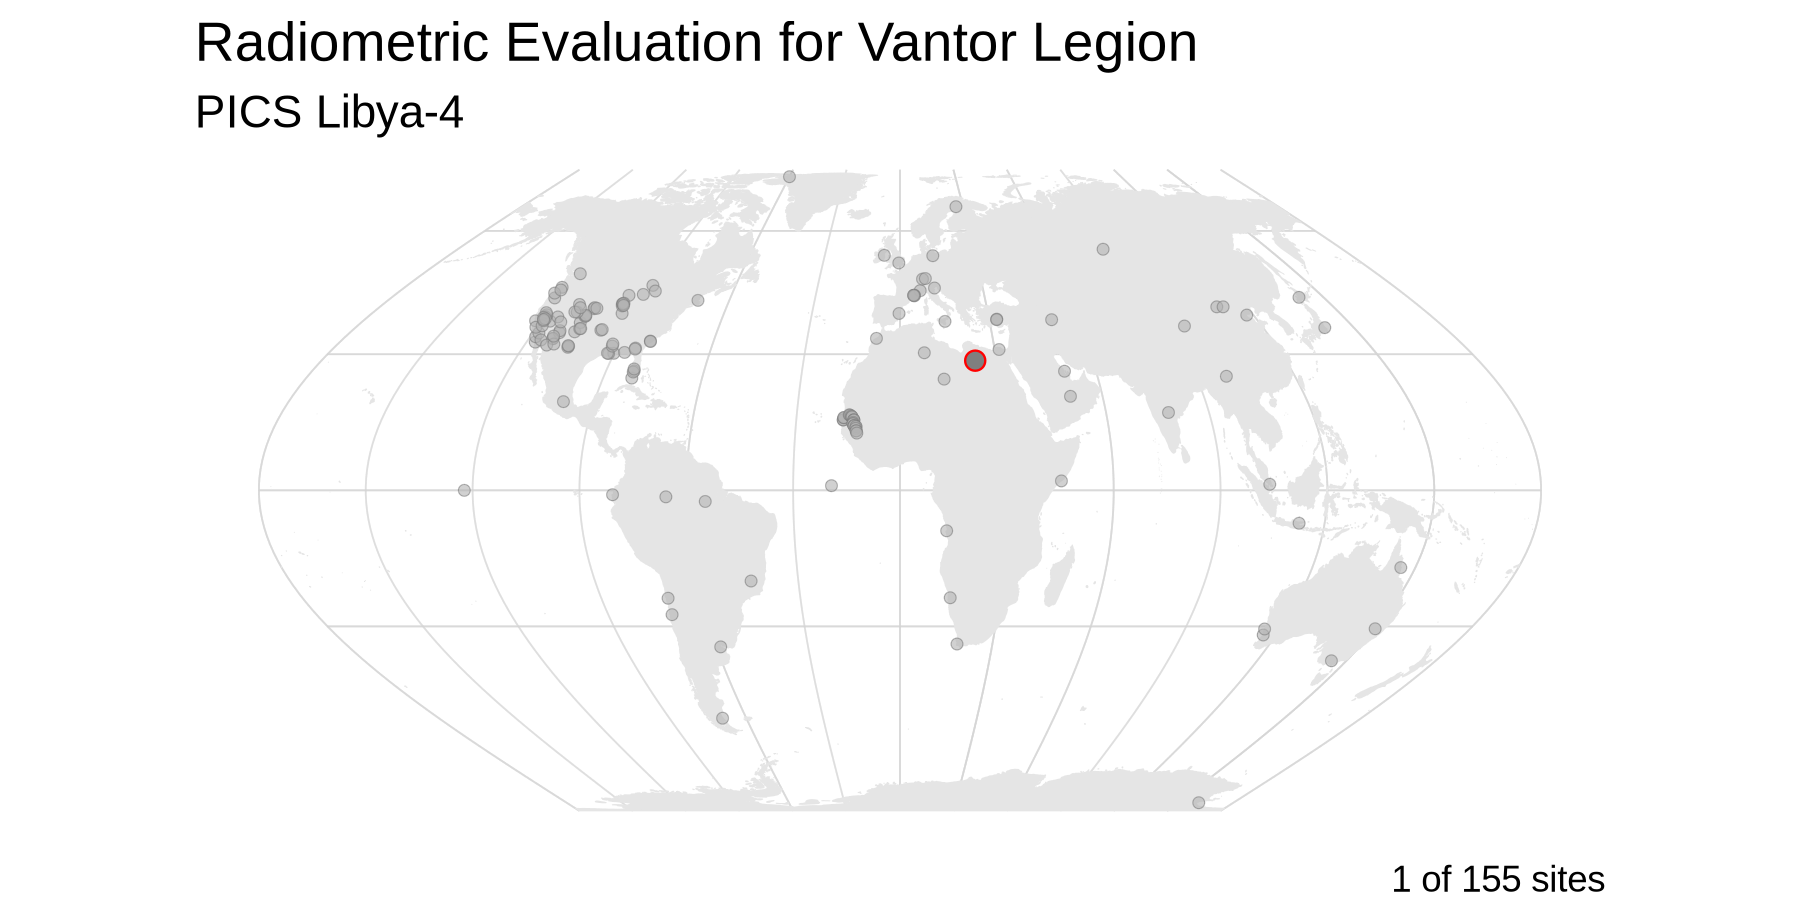

In [42]:
options(repr.plot.width = 6, repr.plot.height = 3, repr.plot.res = 300)

maps <- make_eval_site_overview(
  highlight_sites = c('PICS Libya-4')
)
maps$map_csda + labs(title = 'Radiometric Evaluation for Vantor Legion')

rnaturalearth unavailable, reading continents from local file...

Warning message in st_cast.sf(., "LINESTRING", do_split = TRUE):
“repeating attributes for all sub-geometries for which they may not be constant”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


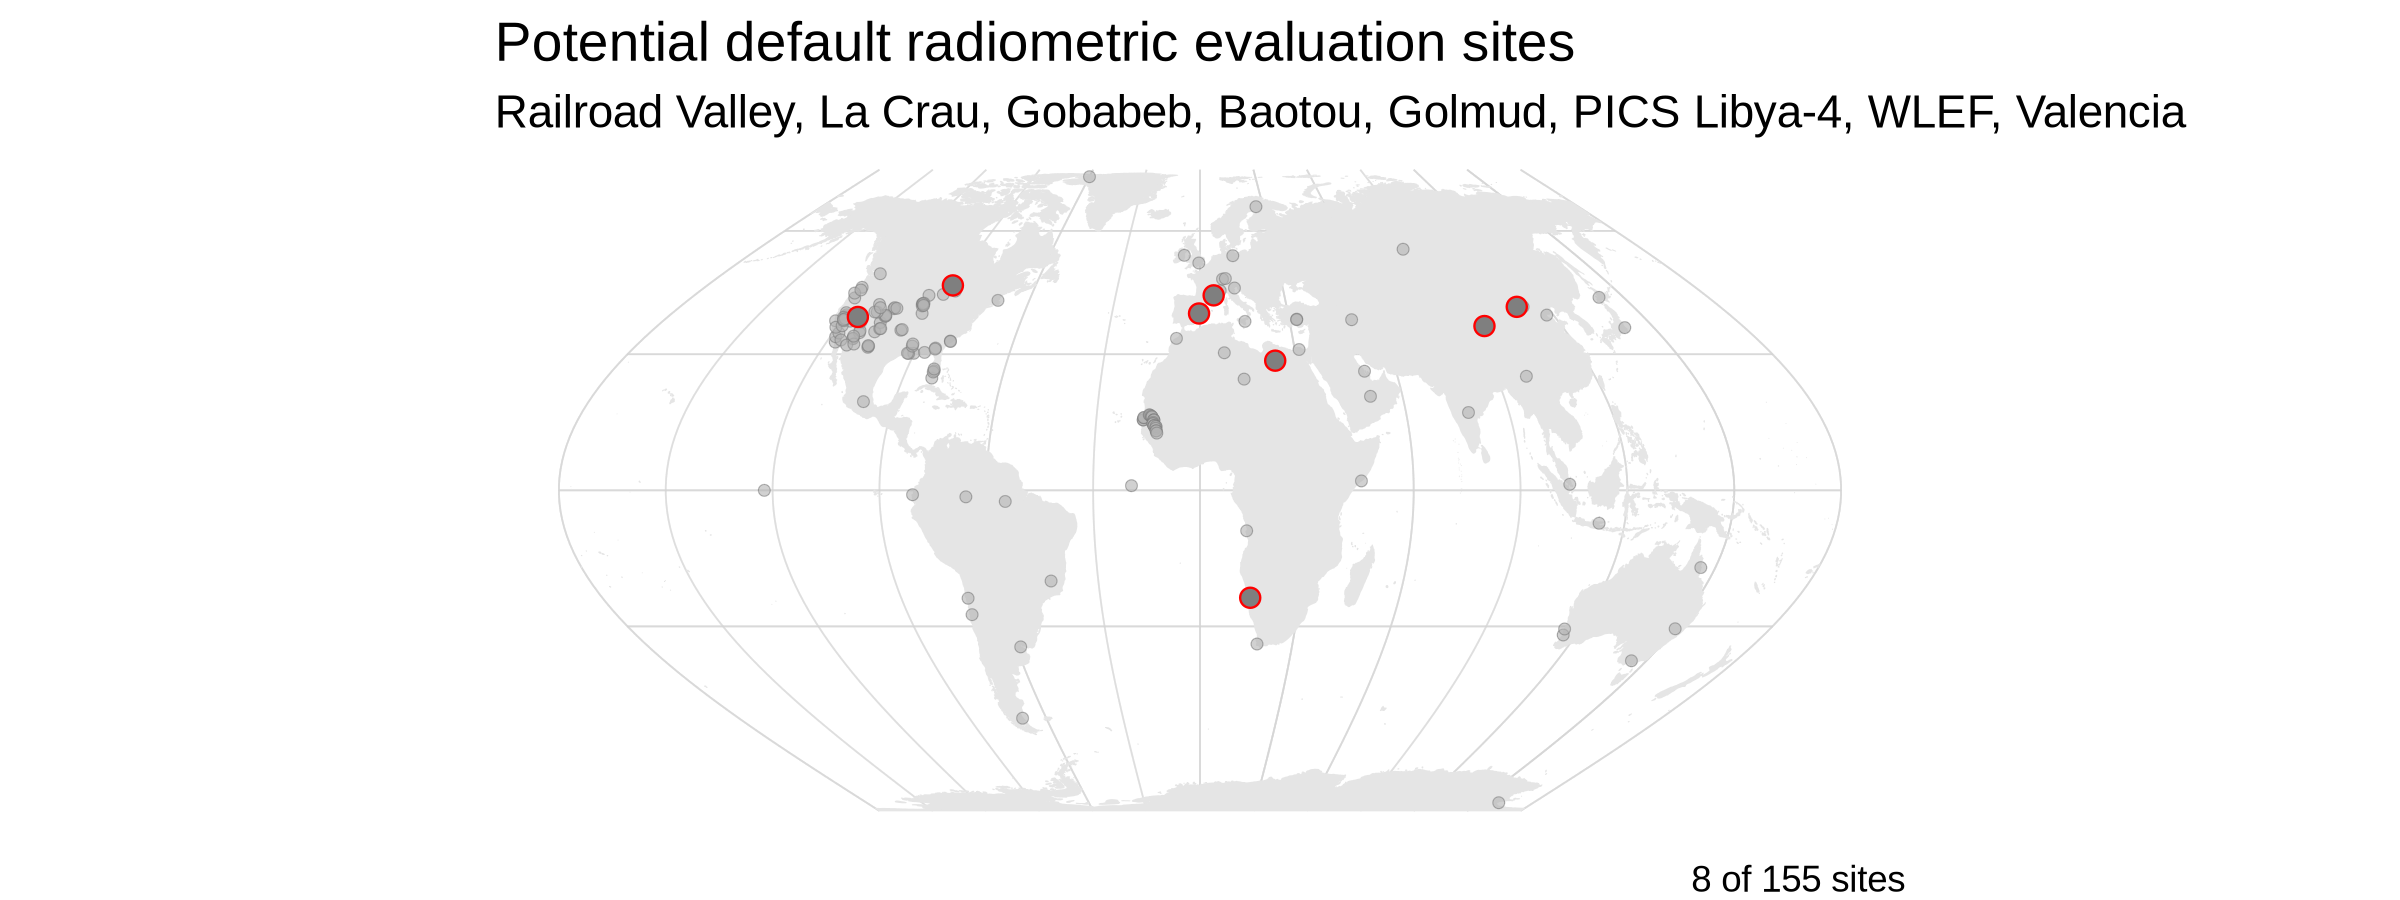

In [45]:
options(repr.plot.width = 8, repr.plot.height = 3, repr.plot.res = 300)

maps <- make_eval_site_overview(
  highlight_sites = c('Railroad Valley', 'La Crau', 'Gobabeb', 'Baotou','Golmud','PICS Libya-4', 'WLEF', 'Valencia')
)
maps$map_csda + labs(title = 'Potential default radiometric evaluation sites')

### Table of image IDs

-- probably should be delivered to `CSDA_eval/results/maxar/legion/radiometric`

## SNR

In [12]:
fn_snr = paste0(MAINDIR, '/snr/Radiometric_evaluation_Vantor_Legion_snr_eachcase.csv')

In [13]:
# Read your data — adjust path
df_snr <- read_csv(fn_snr)

# Set band order (logical wavelength ordering, not alphabetical)
band_order <- c('Coastal', 'Blue', 'Green', 'Yellow', 'Red',
                'RedEdge1', 'RedEdge2', 'NIR1')

df_snr <- df_snr %>%
  mutate(
    Band_name = factor(Band_name, levels = band_order),
    Satellite = factor(Satellite),
    # Parse datetime for nicer labeling
    date = as.Date(substr(`Date_time_in_UTC(YYYYMMDD_HHMMSS)`, 1, 8),
                   format = '%Y%m%d')
  )

Rows: 56 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): Evaluation_type, Vendor, Constellation, Satellite, Site_name, Date_...
dbl (9): Solar_zenith_angle(degree), Solar_azimuth_angle(degree), View_zenit...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [14]:
date_col <- 'Date_time_in_UTC(YYYYMMDD_HHMMSS)'

# Compute counts per satellite (unique acquisitions, ignoring band rows)
sat_counts <- df_snr %>%
  group_by(Satellite) %>%
  summarise(n = n_distinct(.data[[date_col]]), .groups = 'drop')

# Build axis labels: 'LG01' -> 'LG01 (n=2)'
sat_labeller <- setNames(
  paste0(sat_counts$Satellite, ' (n=', sat_counts$n, ')'),
  sat_counts$Satellite
)

# Attach n back onto df_snr so we can map it to point size
df_snr_plot <- df_snr %>% left_join(sat_counts, by = 'Satellite')

p2_snr <- ggplot(df_snr_plot,
             aes(x = Satellite,
                 y = Signal_to_noise_ratio,
                 fill = Band_name)
                 ) +
  geom_jitter(width = 0.15, alpha = 0.85, shape = 21,
              color = 'black', stroke = 0.3) +
  scale_x_discrete(labels = sat_labeller) +
  scale_fill_manual(values = band_colors, name = 'Band') +
  labs(
    title = 'SNR by Legion satellite',
    subtitle = 'Points are individual acquisitions',
    x = NULL,
    y = 'Signal-to-noise ratio'
  ) +
  theme_bw(base_size = 11) +
  theme(panel.grid.minor = element_blank())

In [15]:
p3_snr <- df_snr %>%
  group_by(Satellite, Band_name) %>%
  summarise(
    snr_mean = mean(Signal_to_noise_ratio, na.rm = TRUE),
    snr_min  = min(Signal_to_noise_ratio,  na.rm = TRUE),
    snr_max  = max(Signal_to_noise_ratio,  na.rm = TRUE),
    n        = as.integer(n()),                          # ← force integer
    .groups  = 'drop'
  ) %>%
  ggplot(aes(x = snr_mean, y = Band_name,
             xmin = snr_min, xmax = snr_max,
             color = Satellite,
             size = n)) +
  geom_pointrange(position = position_dodge(width = 0.5),
                  linewidth = 0.7, fatten = 3, shape=21) +
  scale_color_manual(values = sat_colors, name = 'Satellite') +
scale_size_continuous(range = c(0.3, 1.2),
                      name = '# acquisitions',
                      breaks = function(x) {
                        seq(floor(min(x)), ceiling(max(x)), by = 1)
                      })+
  labs(
    title = 'Mean SNR per band, by Legion satellite',
    subtitle = 'Range bars show min–max across acquisitions',
    x = 'Signal-to-noise ratio',
    y = NULL
  ) +
  coord_flip() +
  theme_bw(base_size = 8) +
  theme(panel.grid.minor = element_blank())

Warning message:
“The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead.”


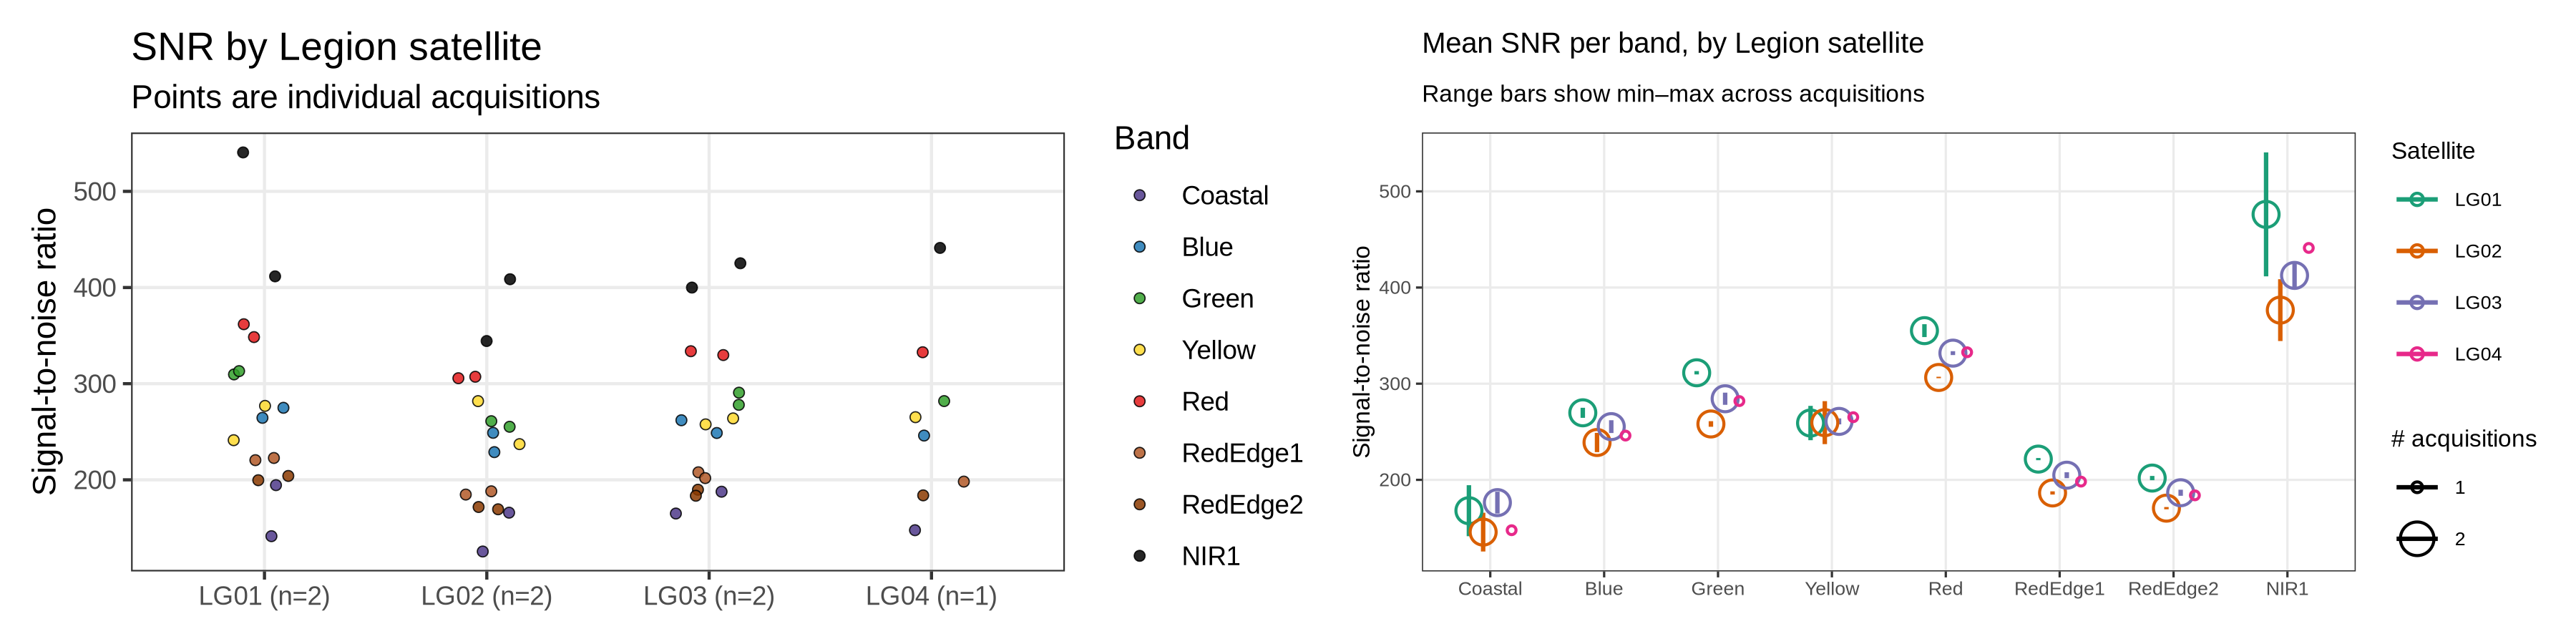

In [16]:
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 300)

p2_snr | p3_snr

## Absolute Calibration

In [17]:
fn_abscal = paste0(MAINDIR, '/abscal/Radiometric_evaluation_Vantor_Legion_abscal_eachcase.csv')

In [18]:
library(tidyverse)
library(viridis)

df_abs <- read_csv(fn_abscal)

band_order <- c('Coastal', 'Blue', 'Green', 'Yellow', 'Red',
                'RedEdge1', 'RedEdge2', 'NIR1')

df_abs <- df_abs %>%
  mutate(
    Band_name = factor(Band_name, levels = band_order),
    Satellite = factor(Satellite),
    date = as.Date(substr(`Date_time_in_UTC(YYYYMMDD_HHMMSS)`, 1, 8),
                   format = '%Y%m%d')
  )

Rows: 56 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): Evaluation_type, Vendor, Constellation, Satellite, Site_name, Date...
dbl (15): Solar_zenith_angle(degree), Solar_azimuth_angle(degree), View_zeni...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
p1_abscal <- ggplot(df_abs, aes(x = Band_name, y = Gain_TOA_reflectance,
                     group = date, color = factor(date))) +
  geom_hline(yintercept = 1, color = 'black', linetype = 'dashed', linewidth = 0.5) +
  #geom_line(linewidth = 0.6, alpha = 0.85) +
  geom_point(size = 2) +
  facet_wrap(~ Satellite, ncol = 1) +
  scale_color_viridis_d(option = 'turbo', name = 'Acquisition\ndate') +
  labs(
    title = 'Legion TOA reflectance gain (measured / reference)',
    subtitle = 'Values closer to 1.0 = better absolute calibration',
    x = NULL,
    y = 'TOA reflectance gain'
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1),
    strip.text = element_text(face = 'bold')
  )

In [20]:
gains_long <- df_abs %>%
  pivot_longer(
    cols = c(Gain_TOA_reflectance,
             Gain_surface_reflectance_1,
             Gain_surface_reflectance_2),
    names_to  = 'gain_type',
    values_to = 'gain'
  ) %>%
  mutate(gain_type = recode(gain_type,
    'Gain_TOA_reflectance'        = 'TOA gain',
    'Gain_surface_reflectance_1'  = 'SR gain (ref 1)',
    'Gain_surface_reflectance_2'  = 'SR gain (ref 2)'
  ),
  gain_type = factor(gain_type,
    levels = c('TOA gain', 'SR gain (ref 1)', 'SR gain (ref 2)'))
  )

p2_abscal <- ggplot(gains_long, aes(x = Band_name, y = gain, color = Satellite)) +
  geom_hline(yintercept = 1, color = 'black', linetype = 'dashed', linewidth = 0.4) +
  geom_jitter(width = 0.18, size = 2, alpha = 0.85, shape=21) +
  facet_wrap(~ gain_type, ncol = 1) +
  scale_color_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'Calibration gains by band — TOA vs. surface reflectance',
    subtitle = 'Each point is one acquisition; dashed line = perfect agreement (1.0)',
    x = NULL,
    y = 'Gain (measured / reference)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))


In [21]:
p3_abscal <- gains_long %>%
  group_by(gain_type, Satellite, Band_name) %>%
  summarise(
    g_mean = mean(gain, na.rm = TRUE),
    g_min  = min(gain,  na.rm = TRUE),
    g_max  = max(gain,  na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  ggplot(aes(x = g_mean, y = Band_name,
             xmin = g_min, xmax = g_max,
             color = Satellite)) +
  geom_vline(xintercept = 1, color = 'black',
             linetype = 'dashed', linewidth = 0.4) +
  geom_pointrange(position = position_dodge(width = 0.5),
                  size = 0.4, linewidth = 0.6, shape=21) +
  facet_wrap(~ gain_type, ncol = 1) +
  scale_color_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'Mean gain per band and satellite, with min–max range',
    subtitle = 'Closer to 1.0 = better absolute calibration',
    x = 'Gain (measured / reference)',
    y = NULL
  ) +
  theme_bw(base_size = 11)


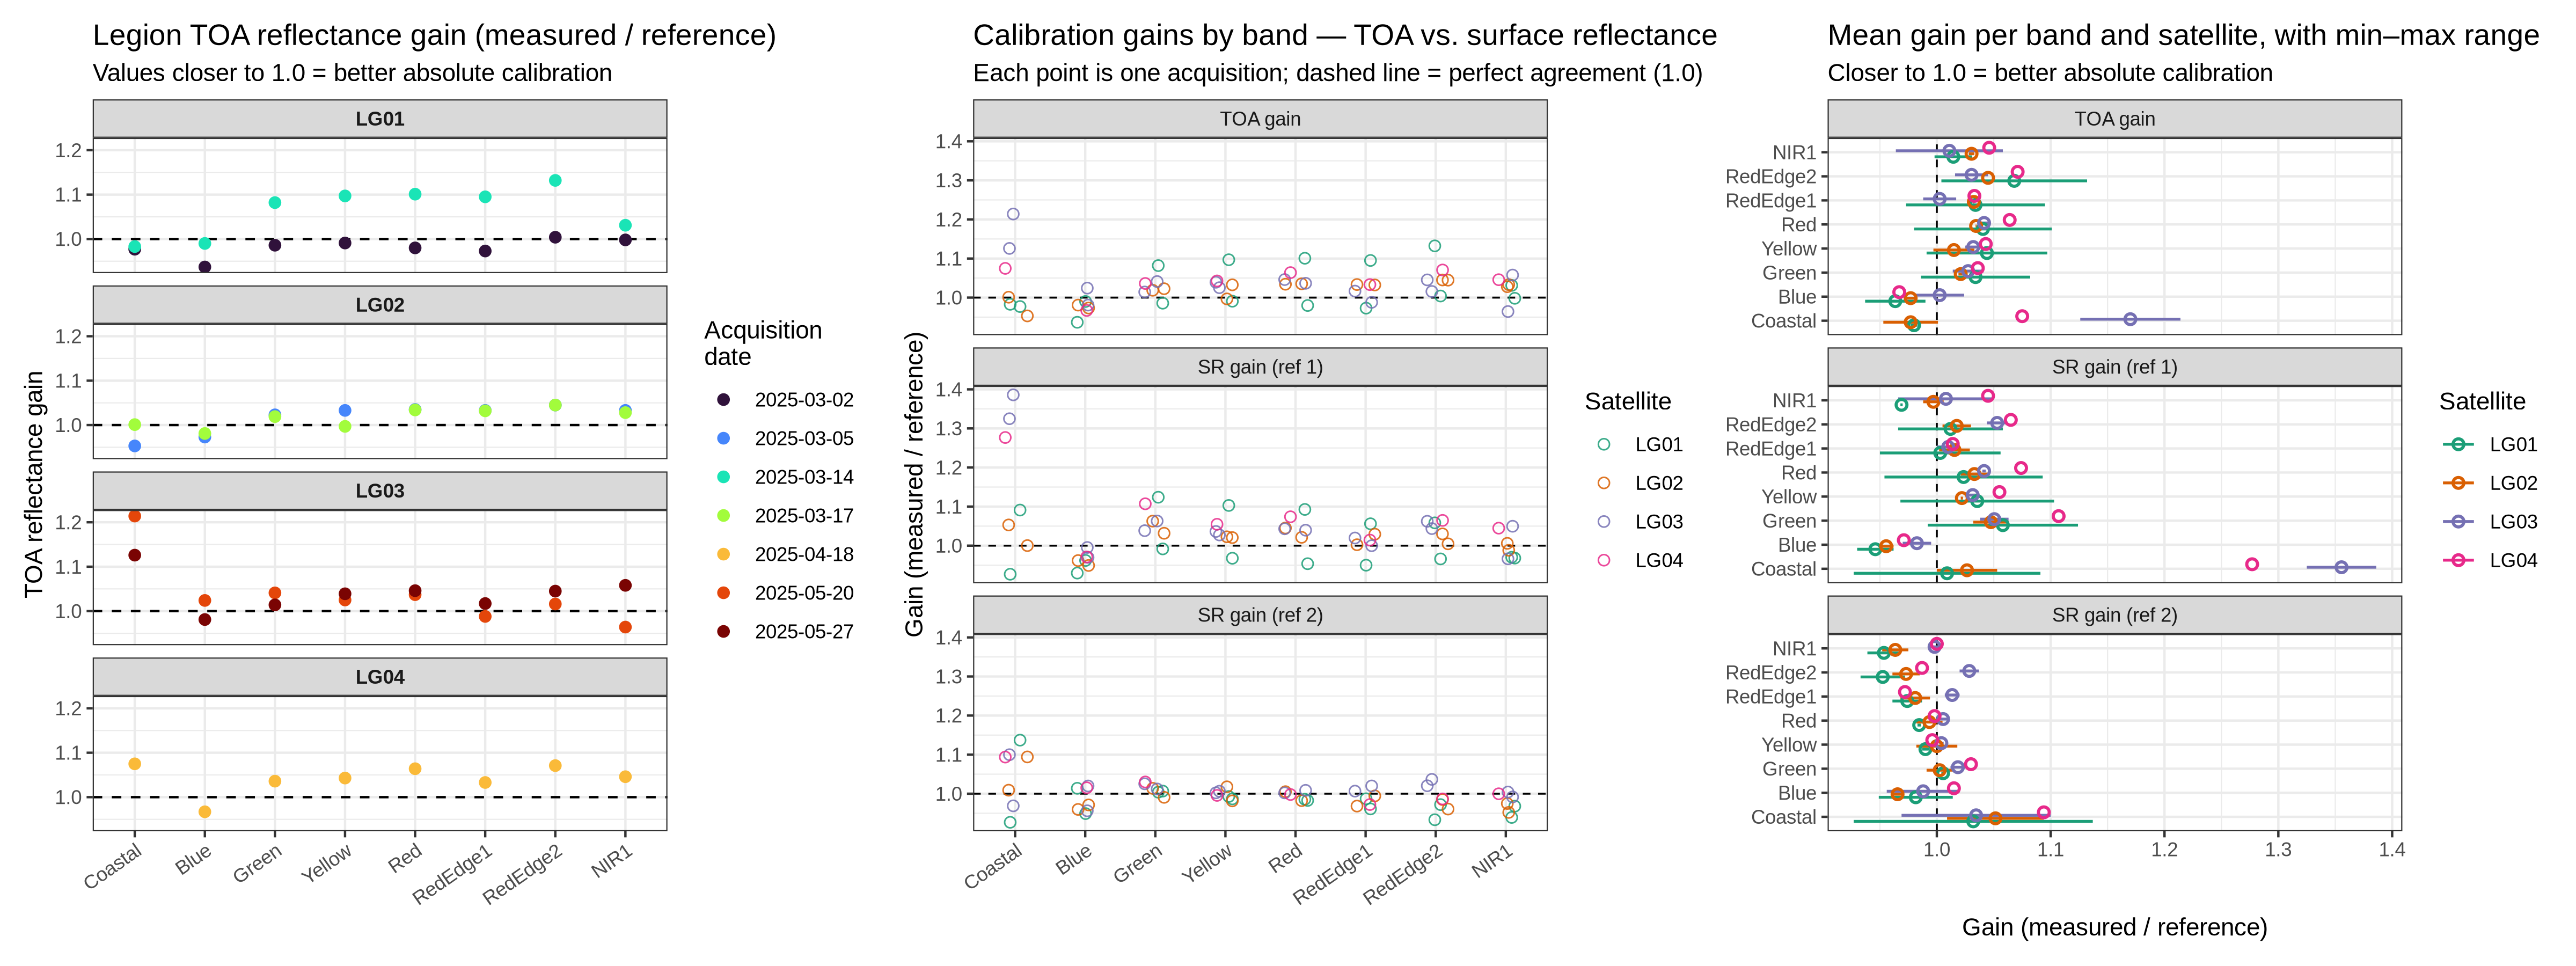

In [22]:
options(repr.plot.width = 16, repr.plot.height = 6, repr.plot.res = 300)

p1_abscal | p2_abscal | p3_abscal

In [26]:
df_abs <- read_csv(fn_abscal) %>%
  mutate(
    date = as.Date(substr(`Date_time_in_UTC(YYYYMMDD_HHMMSS)`, 1, 8),
                   format = '%Y%m%d'),
    Band_name = factor(Band_name,
                       levels = c('Coastal', 'Blue', 'Green', 'Yellow',
                                  'Red', 'RedEdge1', 'RedEdge2', 'NIR1')),
    Satellite = factor(Satellite)
  )

band_colors <- c(
  'Coastal'  = '#4f3a89', 'Blue'     = '#1f78b4',
  'Green'    = '#33a02c', 'Yellow'   = '#ffd92f',
  'Red'      = '#e31a1c', 'RedEdge1' = '#b15928',
  'RedEdge2' = '#8b3a00', 'NIR1'     = '#525252'
)

# Date range across all satellites — make x-axis the same so sparseness is visible
date_range <- range(df_abs$date)

p_timeline_toa_gain <- ggplot(df_abs,
                     aes(x = date,
                         y = Gain_TOA_reflectance,
                         color = Band_name, group = Band_name)) +
  geom_hline(yintercept = 1, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  geom_line(linewidth = 0.5, alpha = 0.85) +
  geom_point(size = 2.2) +
  facet_wrap(~ Satellite, ncol = 1) +
  scale_color_manual(values = band_colors, name = 'Band') +
  scale_x_date(limits = date_range,
               date_labels = '%b %d',
               date_breaks = '14 days') +
  labs(
    title = 'TOA gain timeline: Legion at PICS Libya-4',
    subtitle = paste('Only 1–2 acquisitions per satellite over a ~3-month window.',
                     'Multi-year time series needed to characterize true temporal stability.'),
    x = NULL,
    y = 'TOA gain (measured / reference)',
    caption = 'Each line connects sparse observations of one band over time.'
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.x   = element_text(angle = 30, hjust = 1),
    plot.subtitle = element_text(color = '#a0392f', face = 'italic'),
    plot.caption  = element_text(hjust = 0, color = '#555', size = 9),
    strip.text    = element_text(face = 'bold')
  )

p_timeline_sr <- ggplot(df_abs,
                     aes(x = date,
                         y = Surface_reflectance,
                         color = Band_name, group = Band_name)) +
  geom_hline(yintercept = 1, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  geom_line(linewidth = 0.5, alpha = 0.85) +
  geom_point(size = 2.2) +
  facet_wrap(~ Satellite, ncol = 1) +
  scale_color_manual(values = band_colors, name = 'Band') +
  scale_x_date(limits = date_range,
               date_labels = '%b %d',
               date_breaks = '14 days') +
  labs(
    title = 'Surface reflectance timeline: Legion at PICS Libya-4',
    subtitle = paste('Only 1–2 acquisitions per satellite over a ~3-month window.',
                     'Multi-year time series needed to characterize true temporal stability.'),
    x = NULL,
    y = 'Surface reflectance',
    caption = 'Each line connects sparse observations of one band over time.'
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.x   = element_text(angle = 30, hjust = 1),
    plot.subtitle = element_text(color = '#a0392f', face = 'italic'),
    plot.caption  = element_text(hjust = 0, color = '#555', size = 9),
    strip.text    = element_text(face = 'bold')
  )


Rows: 56 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): Evaluation_type, Vendor, Constellation, Satellite, Site_name, Date...
dbl (15): Solar_zenith_angle(degree), Solar_azimuth_angle(degree), View_zeni...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [25]:
head(df_abs)

Evaluation_type,Vendor,Constellation,Satellite,Site_name,Date_time_in_UTC(YYYYMMDD_HHMMSS),Product_level,Solar_zenith_angle(degree),Solar_azimuth_angle(degree),View_zenith_angle(degree),⋯,Band_name,TOA_reflectance_at_normalized_view_geometry,TOA_reflectance_at_normalized_view_geometry_reference,Gain_TOA_reflectance,Surface_reflectance,Surface_reflectance_reference1,Surface_reflectance_reference2,Gain_surface_reflectance_1,Gain_surface_reflectance_2,date
<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,Coastal,0.235,0.240,0.977,0.154,0.141,0.135,1.091,1.137,2025-03-02
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,Blue,0.256,0.273,0.937,0.206,0.221,0.203,0.930,1.014,2025-03-02
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,Green,0.364,0.369,0.986,0.345,0.348,0.343,0.992,1.007,2025-03-02
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,Yellow,0.490,0.495,0.991,0.468,0.483,0.474,0.968,0.987,2025-03-02
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,Red,0.522,0.533,0.980,0.507,0.532,0.516,0.954,0.983,2025-03-02
Radiometric,Vantor,Legion,LG01,PICS Libya-4,20250302_090641,M2AS and M3DS,41.8,144.5,19.4,⋯,RedEdge1,0.542,0.557,0.973,0.536,0.564,0.543,0.950,0.987,2025-03-02


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


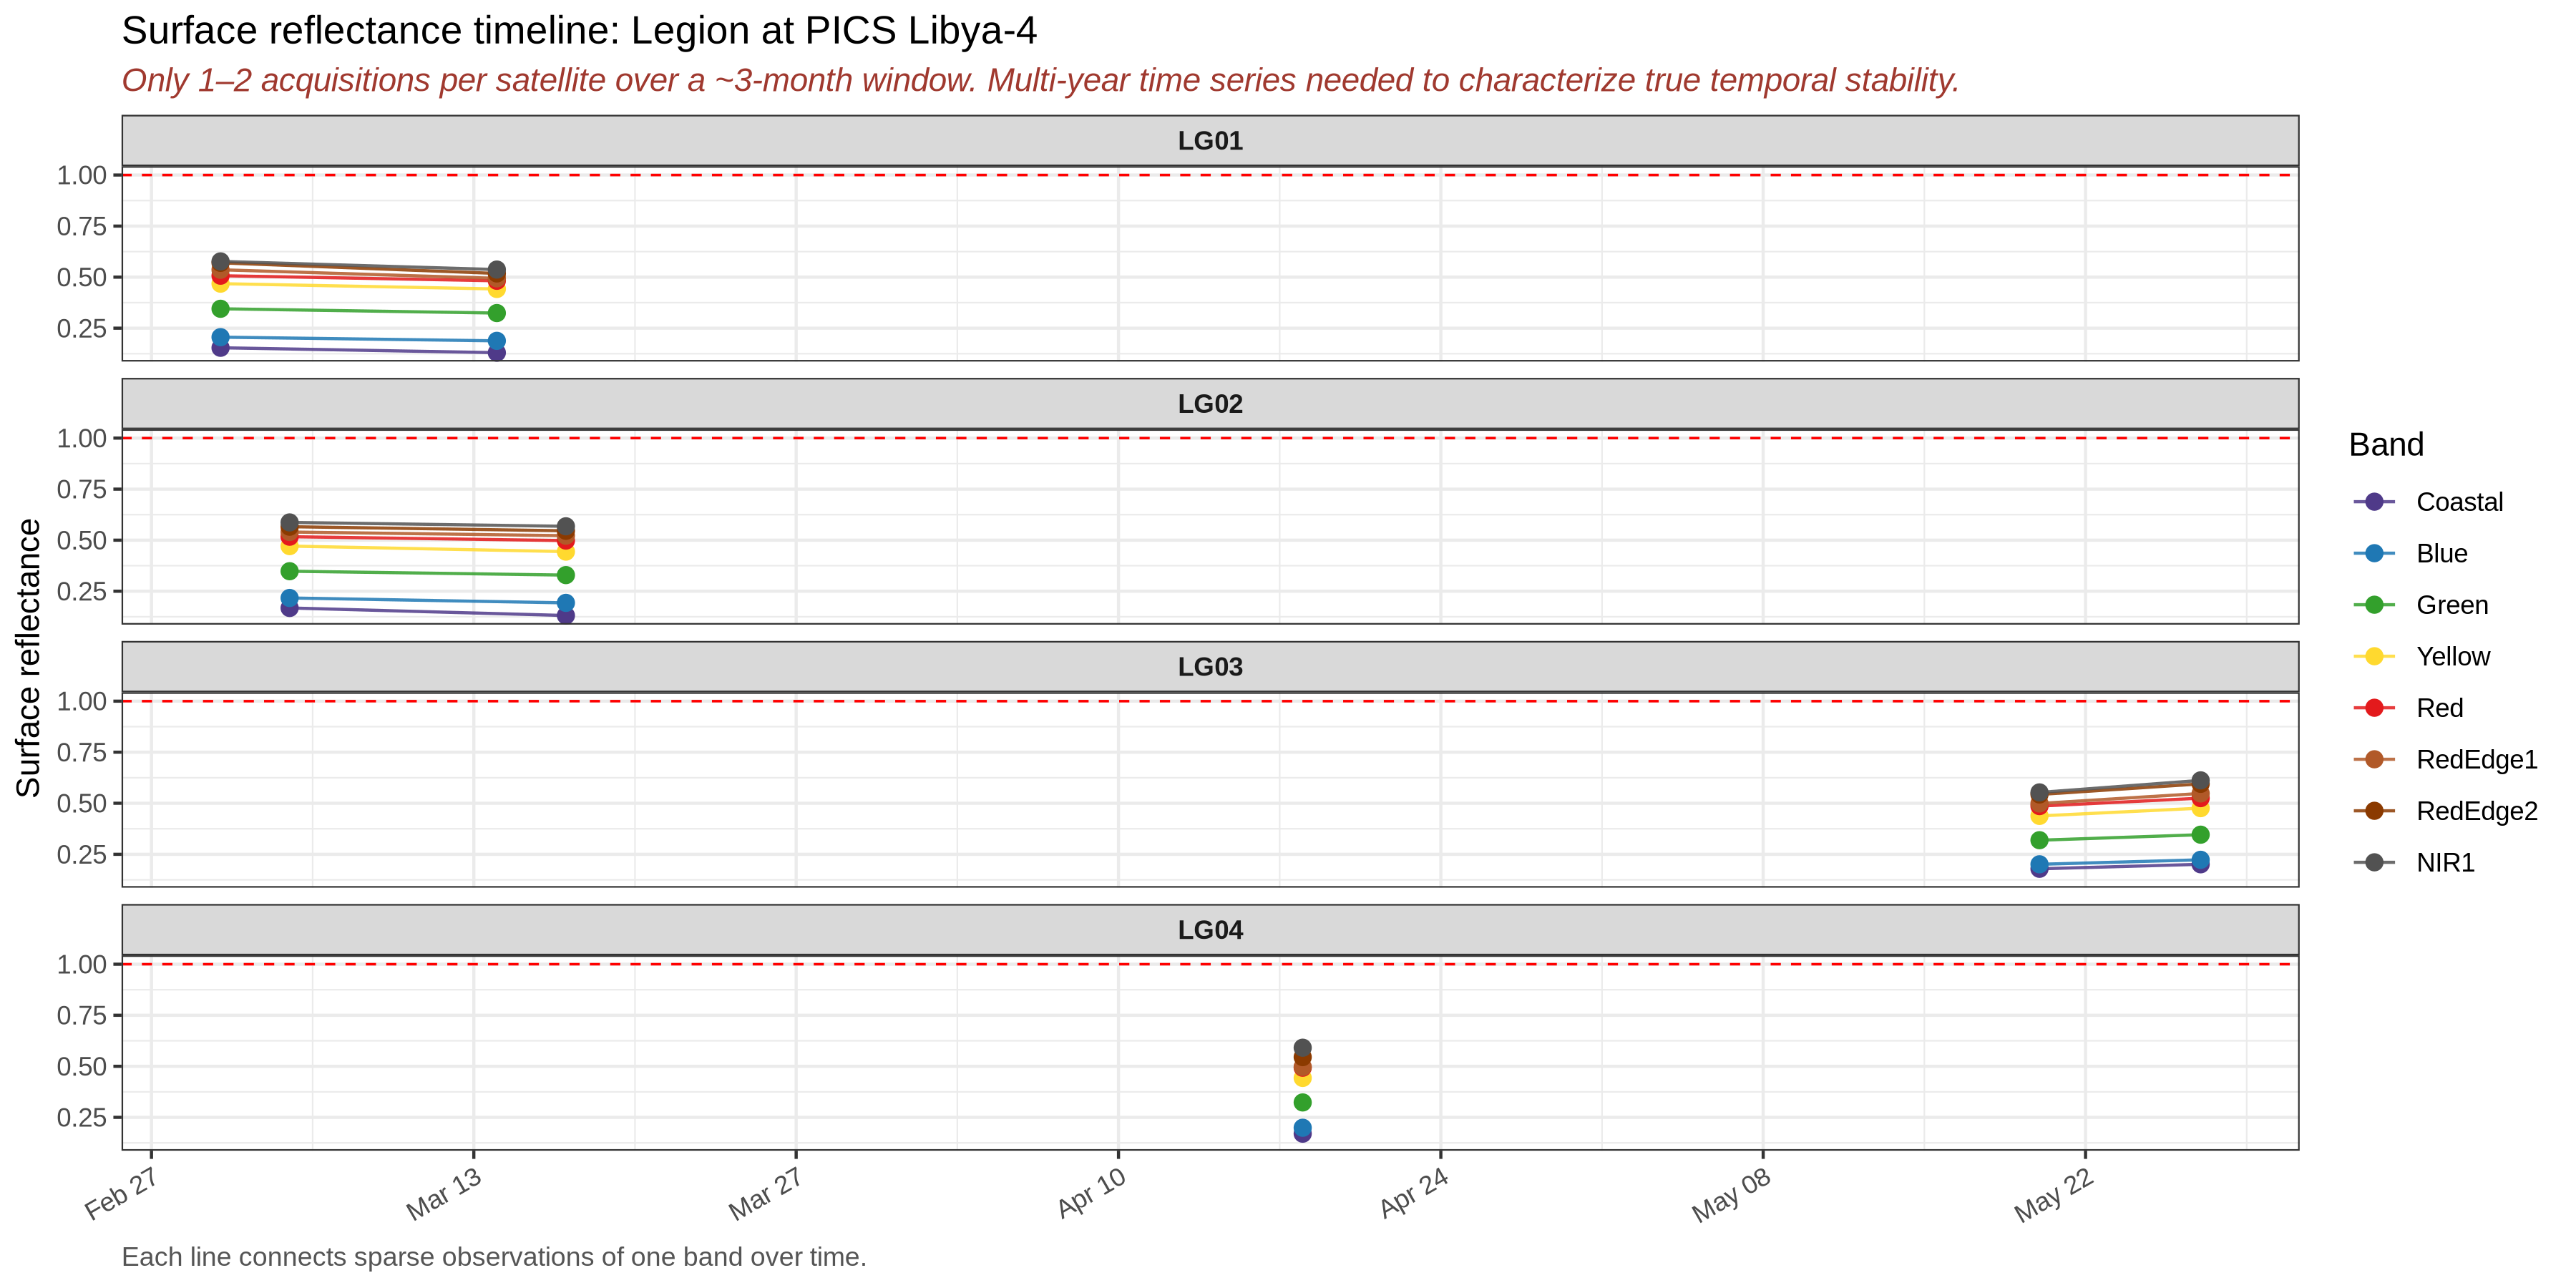

In [27]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 300)

p_timeline_sr

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


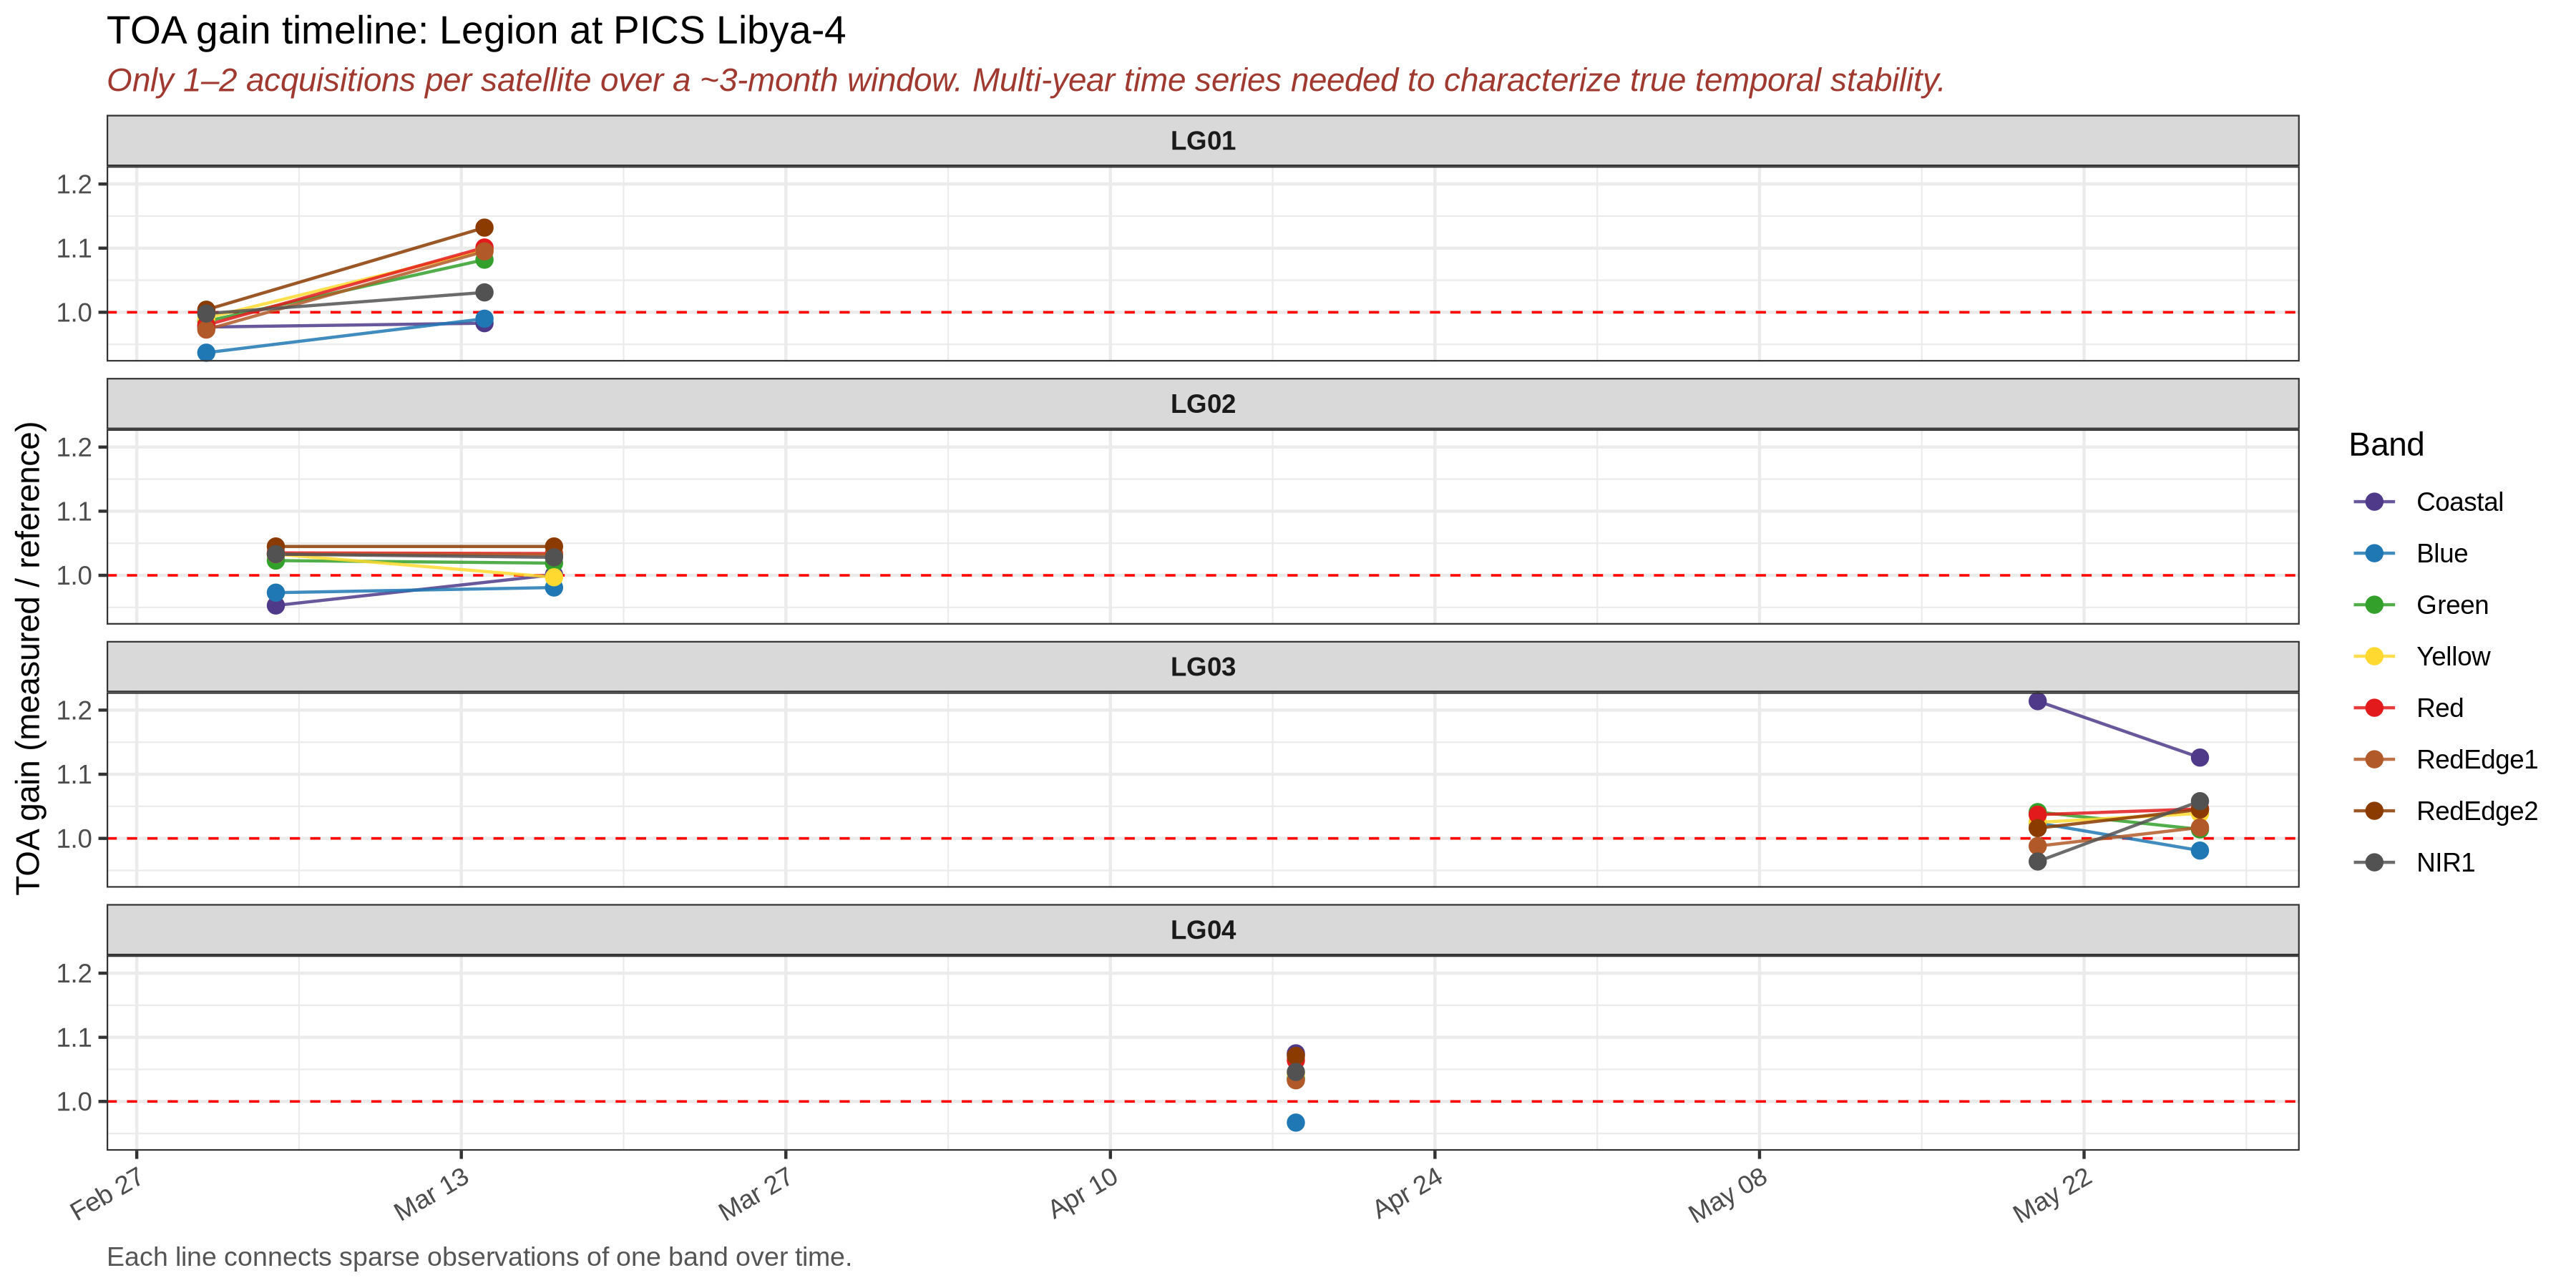

In [144]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 300)

p_timeline_toa_gain

#### Bring in Vendor Specs DB to get useful context

In [35]:
# ---- Read vendor specs from Google Sheets (CSV export) ----
specs_url <- 'https://docs.google.com/spreadsheets/d/13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k/export?format=csv&gid=1094438485'

specs <- read_csv(specs_url) %>%
  # Map "Legion-1" → "LG01" to match your data
  mutate(
    Satellite = str_replace(`Sensor Name`, 'LG-(\\d+)',
                            function(x) sprintf('LG%02d', as.integer(str_extract(x, '\\d+')))),
    `Launch Date` = as.Date(`Launch Date`)
  ) %>%
  filter(Satellite %in% levels(df_abs$Satellite)) %>%
  select(Satellite, `Launch Date`)

print(specs)

New names:
• `` -> `...98`
Rows: 71 Columns: 98
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (30): Sensor Name, Constellation/Platform, Start Date, End Date, Brande...
dbl  (52): Weight Range (kg), Orbit Altitude (km), Revisit Time (days, < 20 ...
lgl  (15): Downlink Latency (min, median), Approx. Instrument Duty Cycle (mi...
date  (1): Launch Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 4 × 2
  Satellite `Launch Date`
  <chr>     <date>       
1 LG01      2024-05-02   
2 LG02      2024-05-02   
3 LG03      2024-08-15   
4 LG04      2024-08-15   


In [37]:
specs

Satellite,Launch Date
<chr>,<date>
LG01,2024-05-02
LG02,2024-05-02
LG03,2024-08-15
LG04,2024-08-15


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


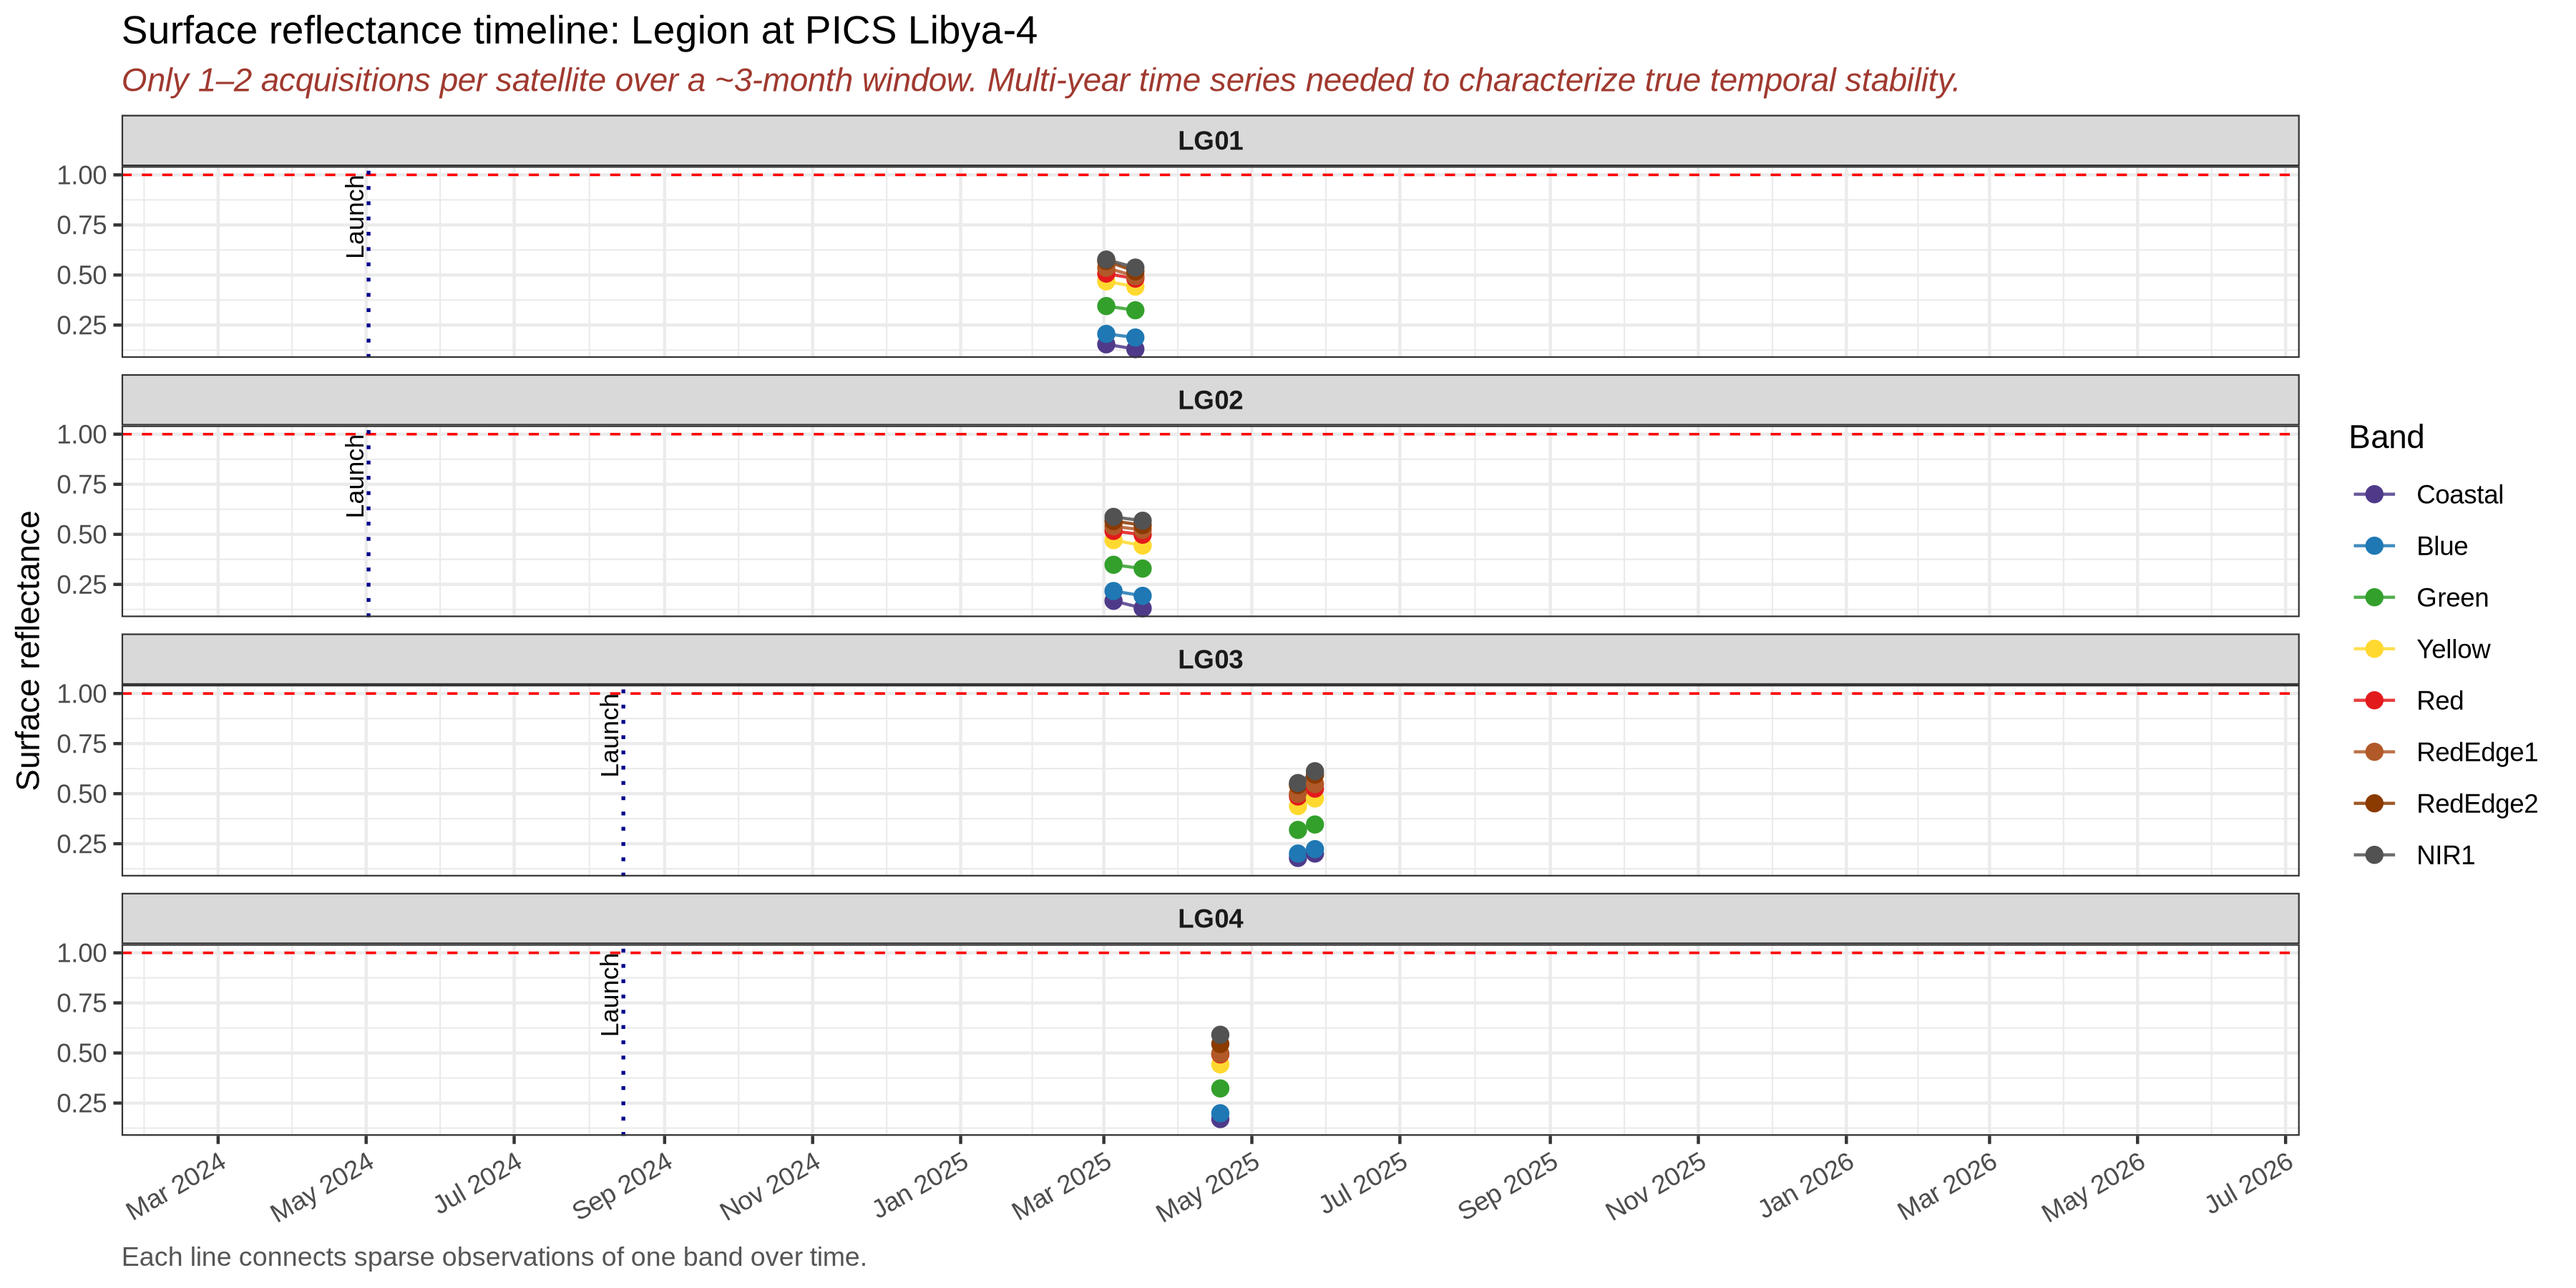

In [38]:
# Add a shaded "needed time series" annotation
p_timeline_sr +
  geom_vline(data = specs,
             aes(xintercept = `Launch Date`),
             color = 'darkblue', linetype = 'dotted', linewidth = 0.6) +
  geom_text(data = specs,
            aes(x = `Launch Date`, y = Inf, label = 'Launch'),
            inherit.aes = FALSE,
            color = 'black', size = 3, angle = 90,
            vjust = -0.3, hjust = 1.1) +
  # annotate('rect', xmin = date_range[1], xmax = date_range[1] + 730,
  #          ymin = -Inf, ymax = Inf, fill = '#ffc0a0', alpha = 0.15) +
  # annotate('text', x = date_range[1] + 365, y = Inf,
  #          label = '← This is what we have',
  #          vjust = 1.5, hjust = 0.5, size = 3.2, color = '#a0392f',
  #          fontface = 'italic') +
  # annotate('text', x = date_range[2] + 60, y = Inf,
  #          label = 'A multi-year baseline\n(2+ years per satellite)\nis needed for drift assessment →',
  #          vjust = 1.5, hjust = 0, size = 3.2, color = '#555',
  #          fontface = 'italic') +
  scale_x_date(limits = c(date_range[1] - 365, date_range[2] + 365),
               date_labels = '%b %Y',
               date_breaks = '2 months')

## Temporal Stability

In [136]:
fn_tempstab = paste0(MAINDIR, '/tempstab/Radiometric_evaluation_Vantor_Legion_tempstab_summary.csv')

In [186]:
df_tempstab

Evaluation_type,Vendor,Constellation,Satellite,Site_name,Product_level,Number_of_images,Time_series_date_min(YYYYMMDD),Time_series_date_max(YYYYMMDD),Time_series_length(days),⋯,drift_SR,drift_SR_ref1,drift_SR_ref2,cv_SR,cv_SR_ref1,cv_SR_ref2,drift_GainSR1,cv_GainSR1,drift_GainSR2,cv_GainSR2
<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-516.2902,-22.4131,103.4280,8.486,0.368,1.700,-494.2305,8.123,-618.8525,10.172
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-271.3786,-372.5946,-69.6396,4.460,6.124,1.145,101.1394,1.662,-201.8585,3.318
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-188.3340,-569.6069,-180.0276,3.096,9.362,2.959,381.8035,6.275,-8.3170,0.137
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-172.9258,-567.8729,-189.1595,2.842,9.334,3.109,395.3532,6.498,16.2484,0.267
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-154.0852,-568.2930,-161.9289,2.533,9.341,2.662,414.5559,6.814,7.8498,0.129
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-248.1351,-568.3880,-168.0722,4.078,9.342,2.762,320.8367,5.273,-80.1538,1.317
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-292.2037,-568.0340,-166.4610,4.803,9.336,2.736,276.4731,4.544,-125.9104,2.070
Radiometric,Vantor,Legion,LG01,PICS Libya-4,M2AS and M3DS,2,20250302,20250314,12,⋯,-216.3757,-223.4958,-124.5448,3.556,3.673,2.047,7.2033,0.118,-91.9002,1.510
Radiometric,Vantor,Legion,LG02,PICS Libya-4,M2AS and M3DS,2,20250305,20250317,12,⋯,-736.6113,-889.2464,-492.3570,12.109,14.618,8.094,155.4165,2.555,-246.9889,4.060


In [137]:
df_tempstab <- read_csv(fn_tempstab)

band_order <- c('Coastal', 'Blue', 'Green', 'Yellow', 'Red',
                'RedEdge1', 'RedEdge2', 'NIR1')

df_tempstab <- df_tempstab %>%
  mutate(
    Band_name = factor(Band_name, levels = band_order),
    Satellite = factor(Satellite),
  ) %>%
  filter(Number_of_images >= 2)   # drop LG04 (single acquisition → no stability metric)

# Friendlier column names
df_tempstab <- df_tempstab %>% rename(
  cv_TOA      = `Radiometric_Temporal_Stability_TOA_reflectance(coeff_of_variation%)`,
  cv_TOA_ref  = `Radiometric_Temporal_Stability_TOA_reflectance_reference(coeff_of_variation%)`,
  cv_GainTOA  = `Radiometric_Temporal_Stability_Gain_TOA_reflectance(coeff_of_variation%)`,
  cv_SR       = `Radiometric_Temporal_Stability_Surface_reflectance(coeff_of_variation%)`,
  cv_SR_ref1  = `Radiometric_Temporal_Stability_Surface_reflectance_reference1(coeff_of_variation%)`,
  cv_SR_ref2  = `Radiometric_Temporal_Stability_Surface_reflectance_reference2(coeff_of_variation%)`,
  cv_GainSR1  = `Radiometric_Temporal_Stability_Gain_Surface_reflectance_1(coeff_of_variation%)`,
  cv_GainSR2  = `Radiometric_Temporal_Stability_Gain_Surface_reflectance_2(coeff_of_variation%)`,
  
  drift_TOA      = `Radiometric_Temporal_Stability_TOA_reflectance(%/year)`,
  drift_TOA_ref  = `Radiometric_Temporal_Stability_TOA_reflectance_reference(%/year)`,
  drift_GainTOA  = `Radiometric_Temporal_Stability_Gain_TOA_reflectance(%/year)`,
  drift_SR       = `Radiometric_Temporal_Stability_Surface_reflectance(%/year)`,
  drift_SR_ref1  = `Radiometric_Temporal_Stability_Surface_reflectance_reference1(%/year)`,
  drift_SR_ref2  = `Radiometric_Temporal_Stability_Surface_reflectance_reference2(%/year)`,
  drift_GainSR1  = `Radiometric_Temporal_Stability_Gain_Surface_reflectance_1(%/year)`,
  drift_GainSR2  = `Radiometric_Temporal_Stability_Gain_Surface_reflectance_2(%/year)`,
)

Rows: 32 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): Evaluation_type, Vendor, Constellation, Satellite, Site_name, Prod...
dbl (20): Number_of_images, Time_series_date_min(YYYYMMDD), Time_series_date...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [189]:
p1_tempstab <- ggplot(df_tempstab, aes(x = Band_name, y = cv_GainTOA, fill = Satellite)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
geom_text(aes(label = paste0('n=', Number_of_images)),
position = position_dodge(width = 0.8),
vjust = -0.4, size = 2.5, color = '#333') +
  scale_fill_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'Inter-acquisition stability of TOA reflectance gain',
    subtitle = 'CV between multiple acquisitions per satellite',
    x = NULL,
    y = 'Gain CV (%)',
    caption = 'Gain = measured TOA / reference TOA. Lower CV = better sensor stability. Long-term drift cannot be assessed from this short baseline.'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1),
        plot.caption = element_text(hjust = 0, color = '#555', size = 9))


In [197]:
p2_tempstab <- ggplot(df_tempstab, aes(x = Band_name, y = cv_TOA, fill = Satellite)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
geom_text(aes(label = paste0('n=', Number_of_images)),
position = position_dodge(width = 0.8),
vjust = -0.4, size = 2.5, color = '#333') +
  scale_fill_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'TOA reflectance stability: coefficient of variation',
    subtitle = 'lower = more stable across multiple acquisitions',
    x = NULL,
    y = 'TOA CV (%)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

In [203]:
p3_tempstab <- ggplot(df_tempstab, aes(x = Band_name, y = cv_GainTOA, fill = Satellite)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
geom_text(aes(label = paste0('n=', Number_of_images)),
position = position_dodge(width = 0.8),
vjust = -0.4, size = 2.5, color = '#333') +
  scale_fill_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'Gain stability (measured / reference): TOA',
    subtitle = 'CV of TOA reflectance gain. Lower = more stable sensor calibration across acquisitions',
    x = NULL,
    y = 'Gain TOA CV (%)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))


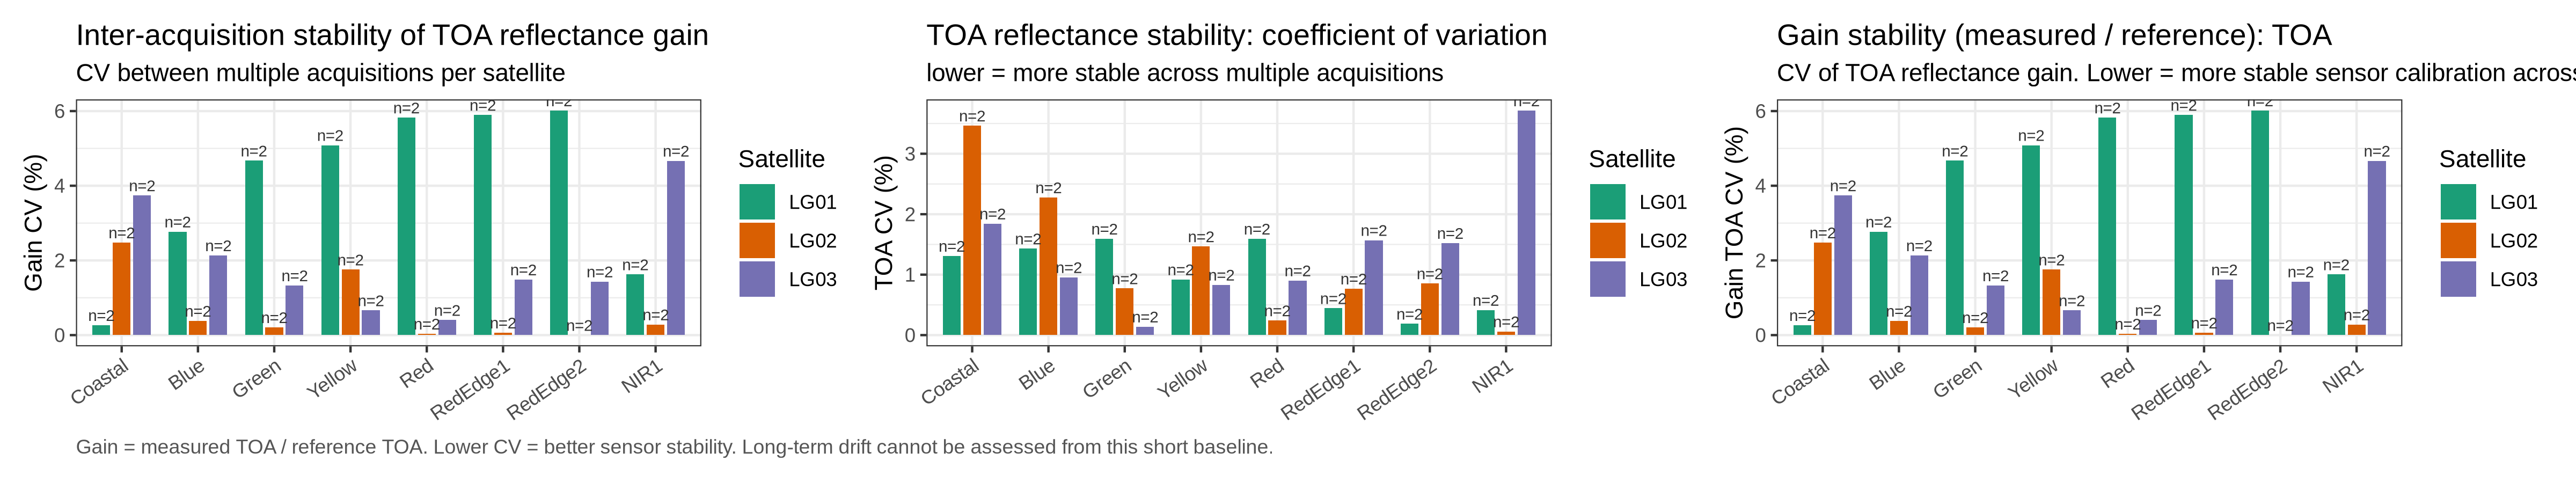

In [204]:
options(repr.plot.width = 16, repr.plot.height = 3, repr.plot.res = 300)
p1_tempstab | p2_tempstab | p3_tempstab

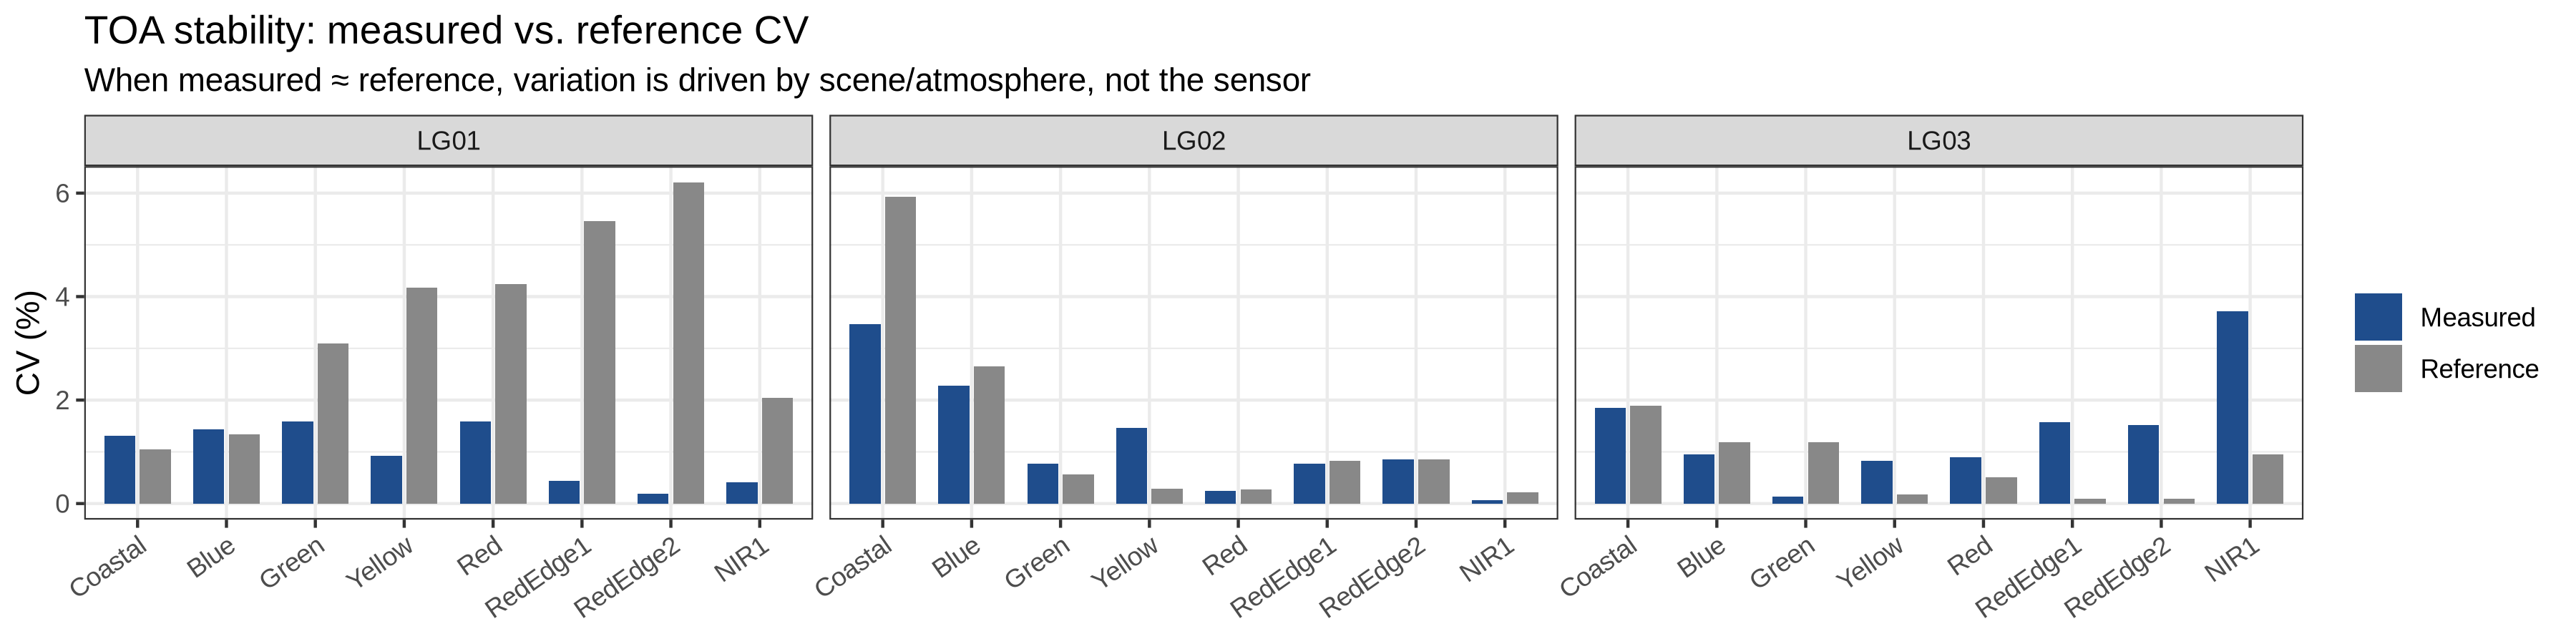

In [193]:
cv_long <- df_tempstab %>%
  pivot_longer(cols = c(cv_TOA, cv_TOA_ref),
               names_to = 'source', values_to = 'cv') %>%
  mutate(source = recode(source,
                         cv_TOA     = 'Measured',
                         cv_TOA_ref = 'Reference'))

p4_tempstab <- ggplot(cv_long, aes(x = Band_name, y = cv, fill = source)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  facet_wrap(~ Satellite, ncol = 3) +
  scale_fill_manual(values = c('Measured' = '#1f4d8c',
                               'Reference' = '#888888'),
                    name = NULL) +
  labs(
    title = 'TOA stability: measured vs. reference CV',
    subtitle = 'When measured ≈ reference, variation is driven by scene/atmosphere, not the sensor',
    x = NULL,
    y = 'CV (%)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

p4_tempstab

In [207]:
gain_cv_long <- df_tempstab %>%
  pivot_longer(cols = c(cv_GainTOA, cv_GainSR1, cv_GainSR2),
               names_to = 'gain_type', values_to = 'cv') %>%
  mutate(gain_type = recode(gain_type,
                            cv_GainTOA = 'TOA gain',
                            cv_GainSR1 = 'SR gain (ref 1)',
                            cv_GainSR2 = 'SR gain (ref 2)'),
         gain_type = factor(gain_type,
                            levels = c('TOA gain', 'SR gain (ref 1)', 'SR gain (ref 2)')))

p5_tempstab <- ggplot(gain_cv_long, aes(x = Band_name, y = cv, color = Satellite)) +
  geom_jitter(width = 0.2, size = 2.5, alpha = 0.85, shape=21) +
  facet_wrap(~ gain_type, ncol = 1) +
  scale_color_manual(values = sat_colors, name = 'Satellite') +
  labs(
    title = 'Gain stability: TOA vs. surface reflectance',
    subtitle = 'CV of (measured / reference). TOA gain isolates sensor stability; SR gain includes atmospheric correction',
    x = NULL,
    y = 'Gain CV (%)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

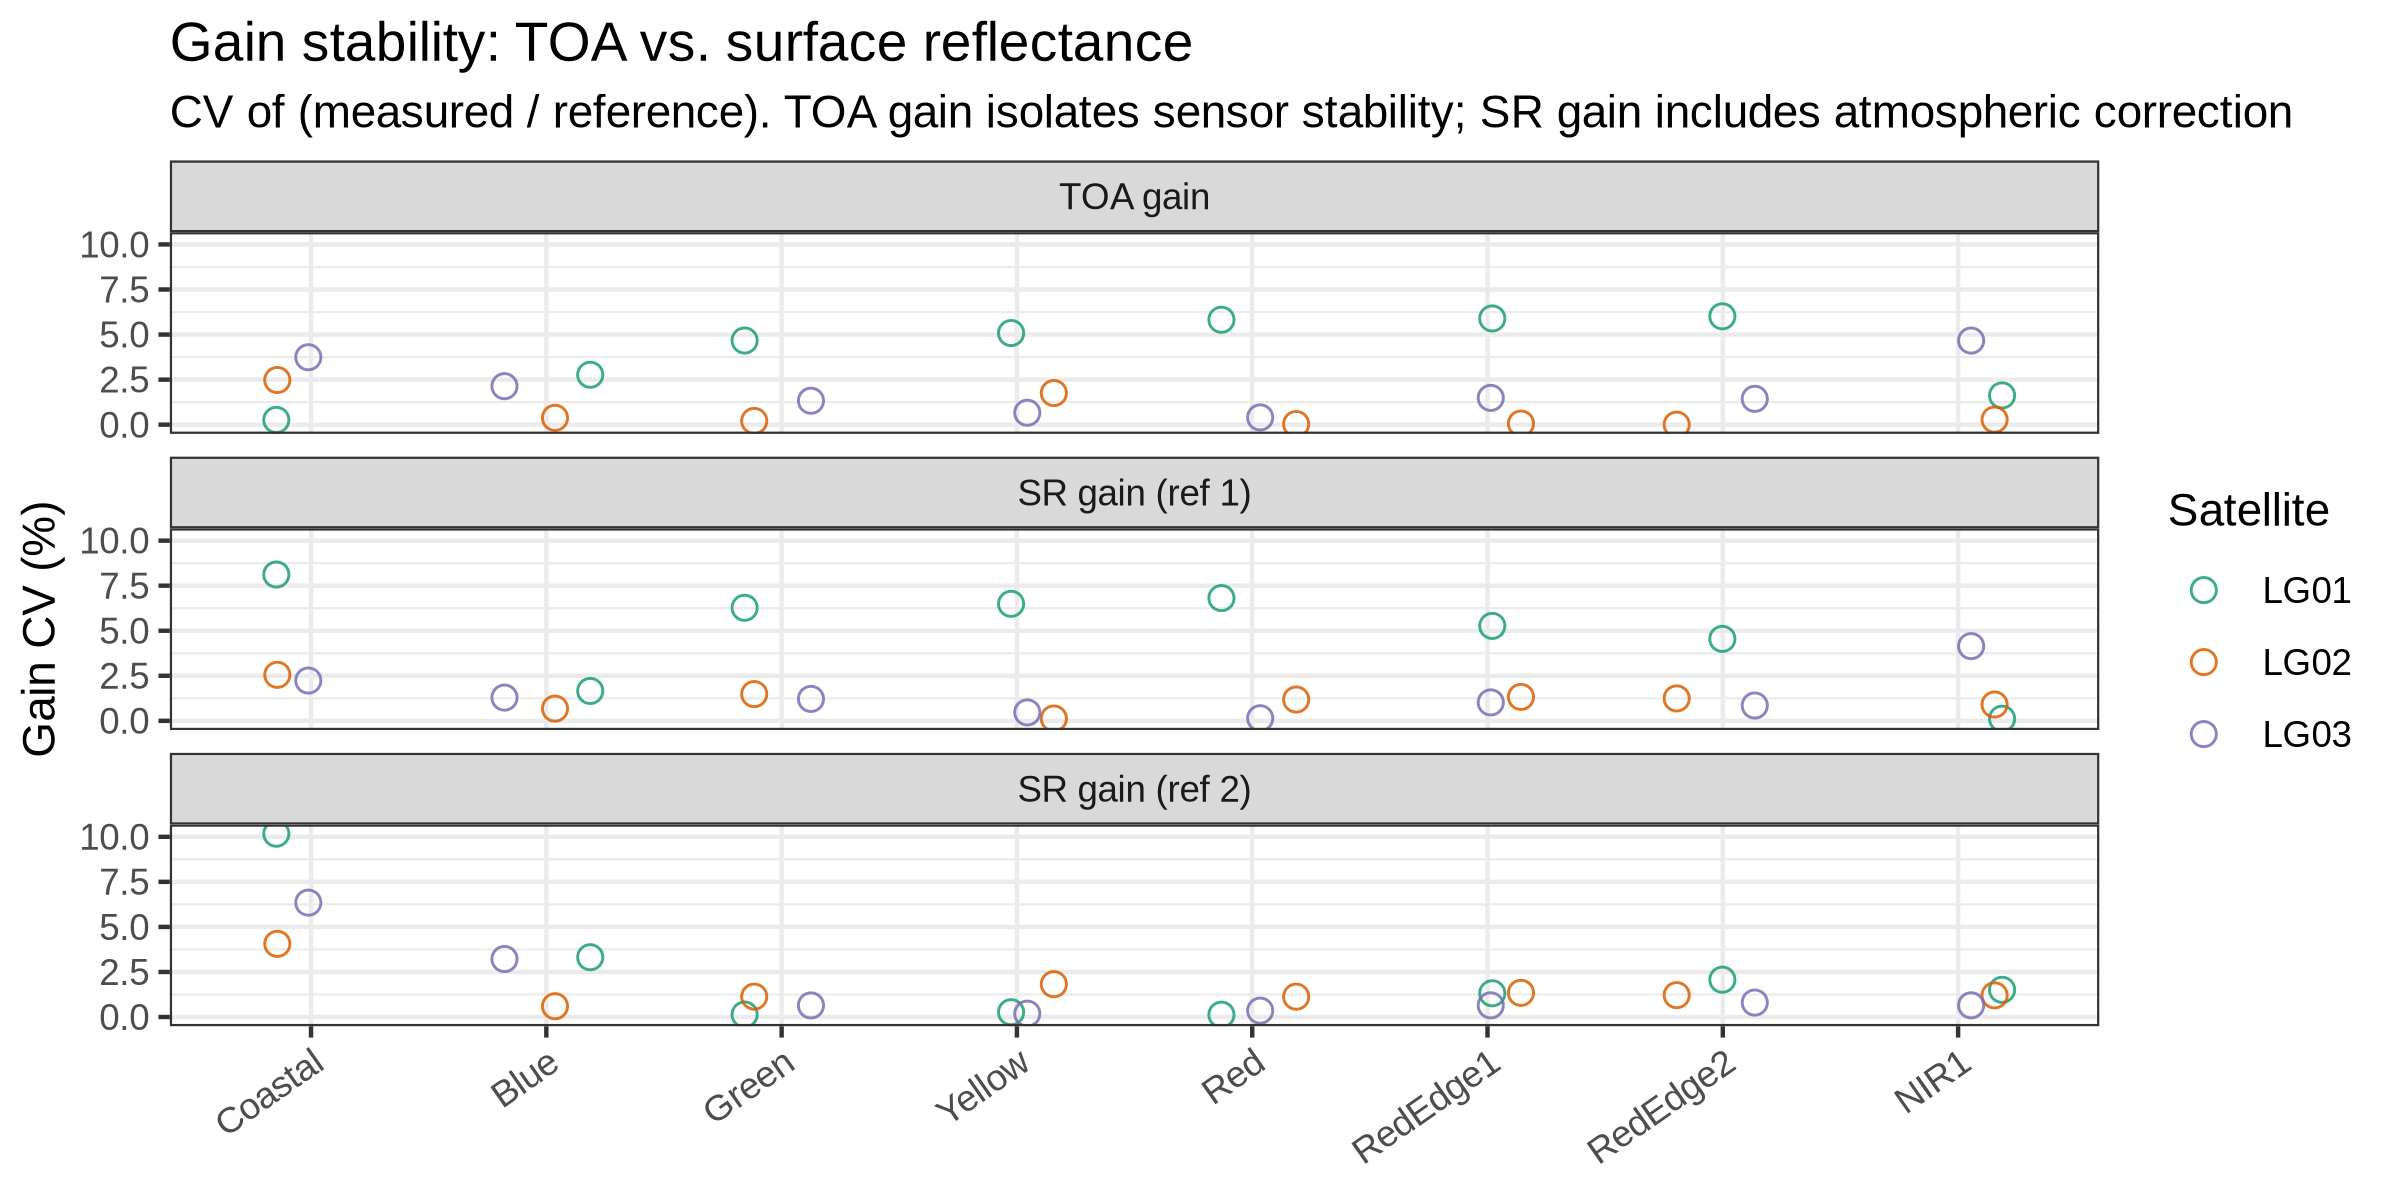

In [211]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 300)
p5_tempstab

### Note useful until we have a long time series

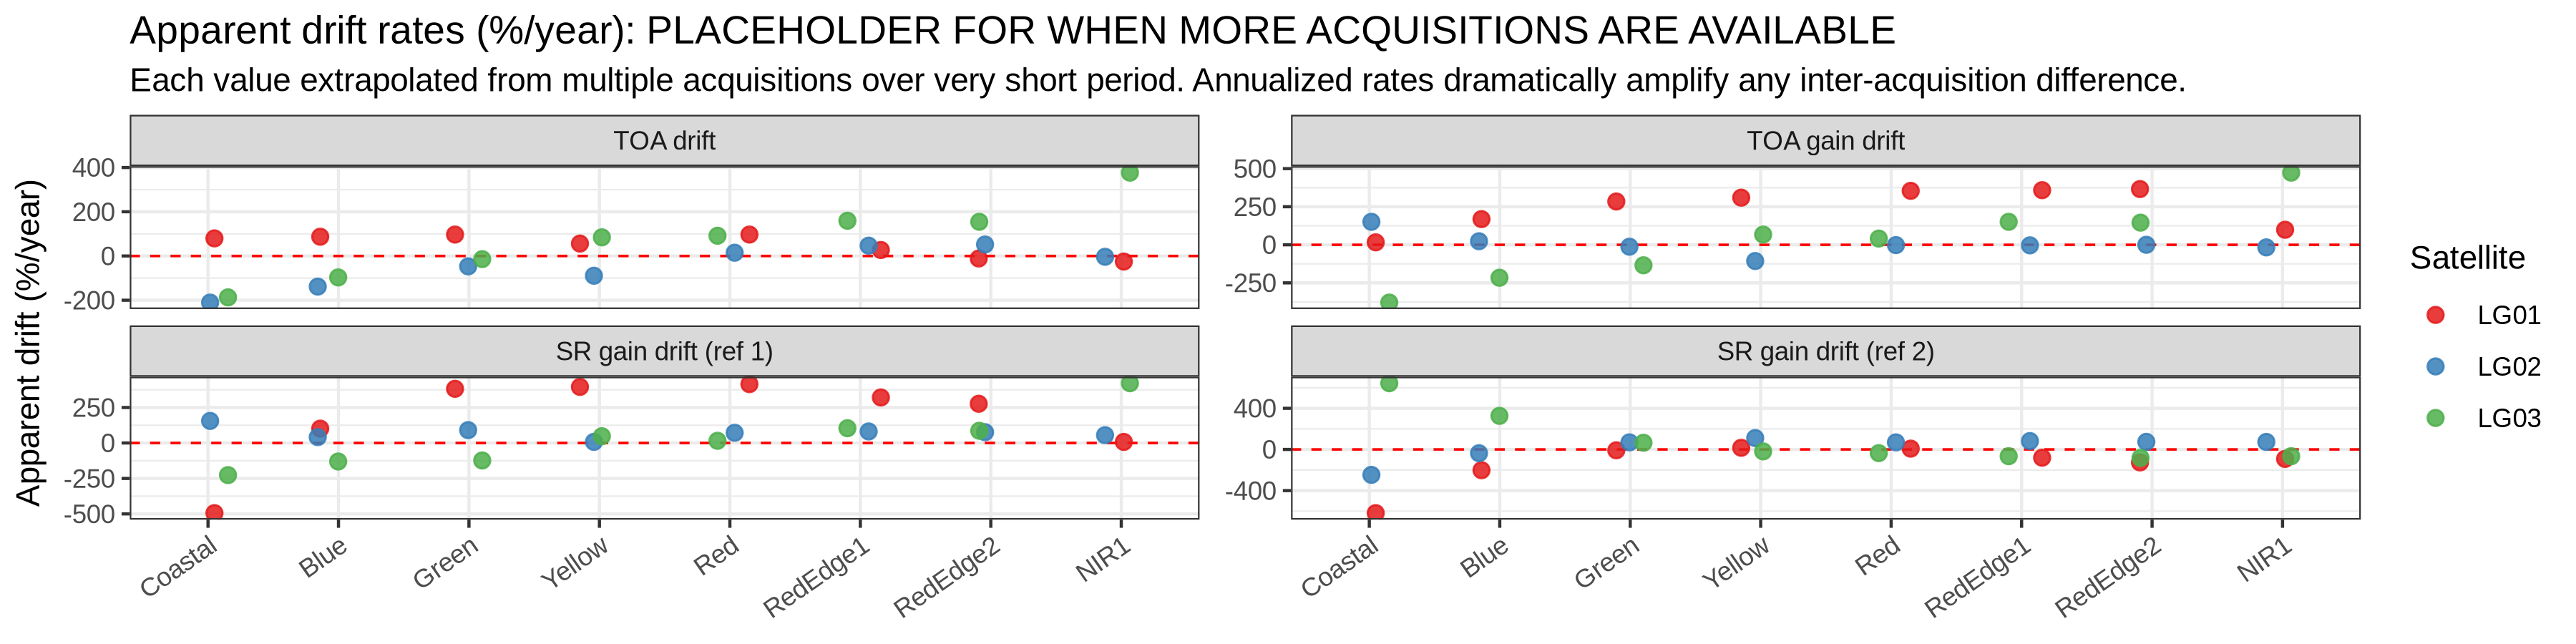

In [160]:
drift_long <- df_tempstab %>%
  pivot_longer(cols = c(drift_TOA, drift_GainTOA, drift_GainSR1, drift_GainSR2),
               names_to = 'metric', values_to = 'drift_pct_yr') %>%
  mutate(metric = recode(metric,
                         drift_TOA      = 'TOA drift',
                         drift_GainTOA  = 'TOA gain drift',
                         drift_GainSR1  = 'SR gain drift (ref 1)',
                         drift_GainSR2  = 'SR gain drift (ref 2)'),
         metric = factor(metric,
                         levels = c('TOA drift', 'TOA gain drift',
                                    'SR gain drift (ref 1)', 'SR gain drift (ref 2)')))

p5 <- ggplot(drift_long, aes(x = Band_name, y = drift_pct_yr, color = Satellite)) +
  geom_hline(yintercept = 0, color = 'red',
             linetype = 'dashed', linewidth = 0.4) +
  geom_jitter(width = 0.18, size = 2.2, alpha = 0.85) +
  facet_wrap(~ metric, ncol = 2, scales = 'free_y') +
  scale_color_brewer(palette = 'Set1', name = 'Satellite') +
  labs(
    title = 'Apparent drift rates (%/year): PLACEHOLDER FOR WHEN MORE ACQUISITIONS ARE AVAILABLE',
    subtitle = 'Each value extrapolated from multiple acquisitions over very short period. Annualized rates dramatically amplify any inter-acquisition difference.',
    x = NULL,
    y = 'Apparent drift (%/year)'
  ) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

p5